In [1]:
import torch
import matplotlib.pyplot as plt
import numpy as np

defining the function as $f(x) = x^4 - 3x^3 + 2$

In [2]:
def f(x):
  return x**4 - 3*x**3 + 2

Plotting $f(x)$ and identifying critical points

To find the critical points analytically, we compute the derivative of the function:

$$
f'(x) = 4x^3 - 9x^2
$$

Factorizing:

$$
f'(x) = x^2(4x - 9)
$$

Setting $f'(x) = 0$, we get the roots:

$$
x = 0 \quad \text{and} \quad x = \frac{9}{4} = 2.25
$$

So, the critical points occur at:
- $x = 0$ (saddle / inflection region)
- $x = 2.25$ (local minimum)

In [3]:
x_range = torch.linspace(-2,4,1000)
y_range = f(x_range)

In [4]:
critical_x = [0.0, 9/4]
critical_y = [f(torch.tensor(cx)).item() for cx in critical_x]

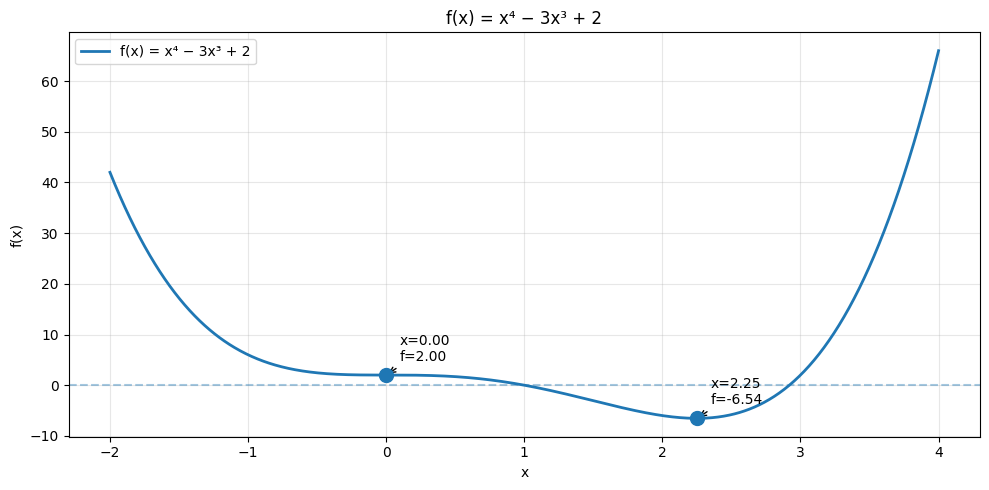

Critical points: x=0 (saddle), x=2.25 (local minimum)


In [5]:
plt.figure(figsize=(10, 5))

plt.plot(x_range.numpy(), y_range.numpy(), linewidth=2,
         label='f(x) = x⁴ − 3x³ + 2')

plt.scatter(critical_x, critical_y, s=100, zorder=5)

for cx, cy in zip(critical_x, critical_y):
    plt.annotate(f'x={cx:.2f}\nf={cy:.2f}',
                 (cx, cy),
                 xytext=(10, 10),
                 textcoords='offset points',
                 arrowprops=dict(arrowstyle='->'))

plt.axhline(0, linestyle='--', alpha=0.4)

plt.xlabel('x')
plt.ylabel('f(x)')
plt.title('f(x) = x⁴ − 3x³ + 2')

plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

print("Critical points: x=0 (saddle), x=2.25 (local minimum)")

Verifying the results against PyTorch's autograd

In [6]:
def f_prime(x):
  return 4*x**3 - 9*x**2

x_test = torch.tensor(2.0, requires_grad=True)
loss = f(x_test)
loss.backward()
print(f'Analytical f\'(2.0) = {f_prime(torch.tensor(2.0)).item():.4f}')

Analytical f'(2.0) = -4.0000


In [7]:
print(f'PyTorch autograd f\'(2.0) = {x_test.grad.item():.4f}')

PyTorch autograd f'(2.0) = -4.0000


In [9]:
print(f'It is matching' if abs(f_prime(torch.tensor(2.0)).item()-x_test.grad.item())<1e-5 else 'Mismatch')

It is matching


Now implementing the Gradient Descent:
We have to minimize $f(x)$ using gradient descent and it will return a list of $(x, f(x))$ tuples at each iteration

In [10]:
def gradient_descent(x0, lr, n_iter=100):
    x = torch.tensor(float(x0), requires_grad=False)
    history = [(x.item(), f(x).item())]
    for _ in range(n_iter):
        grad = f_prime(x)
        x = x - lr * grad
        history.append((x.item(), f(x).item()))
    return history

In [12]:
x0=-1.0
history_demo = gradient_descent(x0, lr=0.01, n_iter=100)
print(f'Start: x={x0}, f(x)={f(torch.tensor(x0)).item():.4f}')
print(f'End:   x={history_demo[-1][0]:.4f}, f(x)={history_demo[-1][1]:.4f}')

Start: x=-1.0, f(x)=6.0000
End:   x=-0.0896, f(x)=2.0022


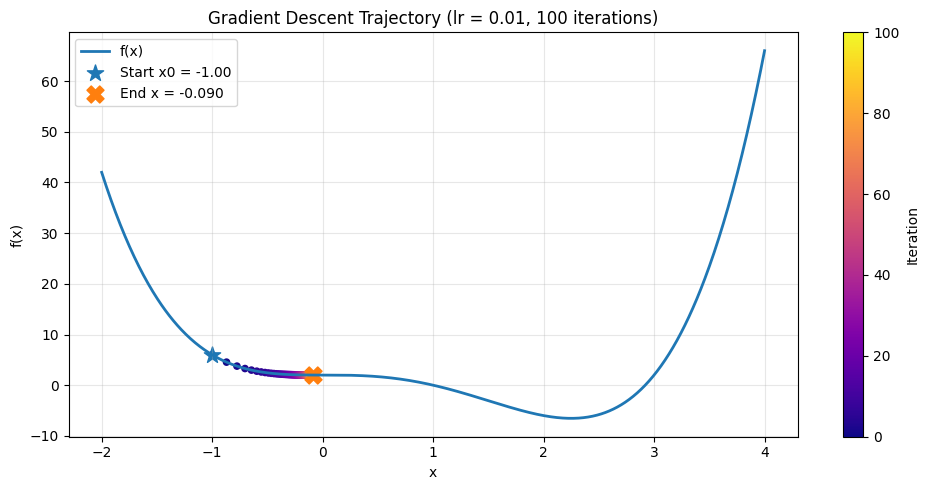

In [13]:
history = gradient_descent(x0=-1.0, lr=0.01, n_iter=100)
xs, ys = zip(*history)

plt.figure(figsize=(10, 5))

plt.plot(x_range.numpy(), y_range.numpy(), linewidth=2, label='f(x)')

sc = plt.scatter(xs, ys, c=range(len(xs)), cmap='plasma', s=20)
plt.colorbar(sc, label='Iteration')

plt.scatter(xs[0], ys[0], marker='*', s=150,
            label=f'Start x0 = {xs[0]:.2f}')
plt.scatter(xs[-1], ys[-1], marker='X', s=150,
            label=f'End x = {xs[-1]:.3f}')

plt.xlabel('x')
plt.ylabel('f(x)')
plt.title('Gradient Descent Trajectory (lr = 0.01, 100 iterations)')
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

Testing how the gradient descent function works with different learning rates.

Learning rate 0.01 -> final x = -0.0896, f(x) = 2.0022
Learning rate 0.05 -> final x = -0.0200, f(x) = 2.0000
Learning rate 0.10 -> final x = 2.3368, f(x) = -6.4627


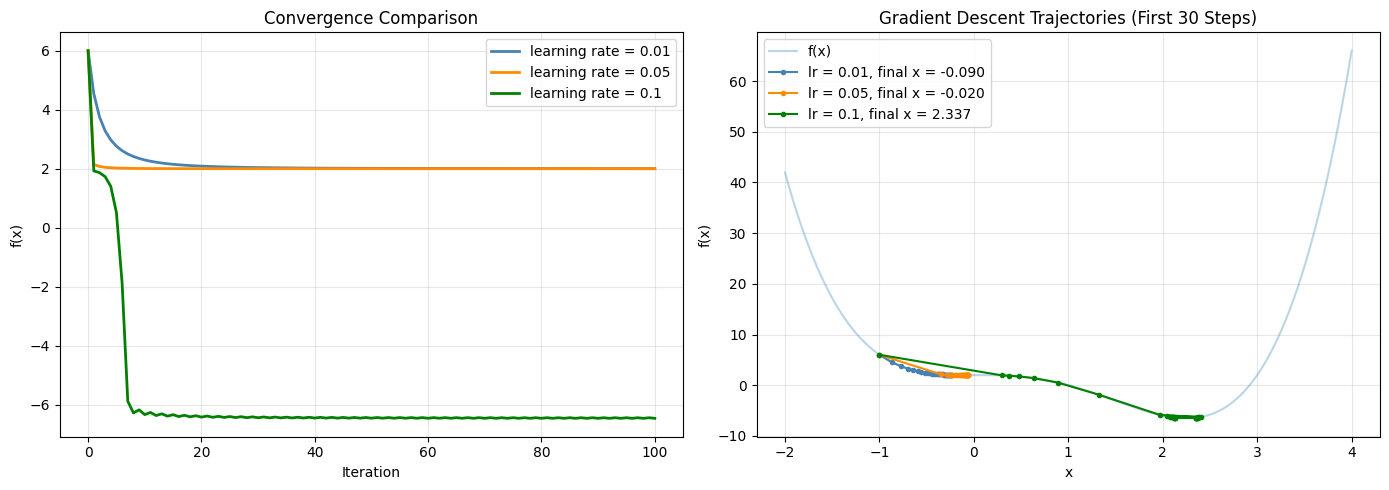


Summary:
0.01 -> slow and stable, converges near saddle region
0.05 -> faster and stable, still near saddle
0.10 -> fastest here, escapes saddle and reaches lower minimum


In [15]:
learning_rates = [0.01, 0.05, 0.1]
colors = ['steelblue', 'darkorange', 'green']

initial_x = -1.0
num_iterations = 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[1].plot(
    x_range.numpy(),
    y_range.numpy(),
    alpha=0.3,
    linewidth=1.5,
    label='f(x)'
)

for lr, color in zip(learning_rates, colors):

    history = gradient_descent(initial_x, lr, num_iterations)
    xs, ys = zip(*history)

    final_x = xs[-1]
    final_y = ys[-1]

    axes[0].plot(
        ys,
        color=color,
        linewidth=2,
        label=f'learning rate = {lr}'
    )

    axes[1].plot(
        xs[:30],
        ys[:30],
        'o-',
        color=color,
        markersize=3,
        linewidth=1.5,
        label=f'lr = {lr}, final x = {final_x:.3f}'
    )

    print(
        f'Learning rate {lr:.2f} -> '
        f'final x = {final_x:.4f}, '
        f'f(x) = {final_y:.4f}'
    )

axes[0].set_xlabel('Iteration')
axes[0].set_ylabel('f(x)')
axes[0].set_title('Convergence Comparison')
axes[0].grid(alpha=0.3)
axes[0].legend()

axes[1].set_xlabel('x')
axes[1].set_ylabel('f(x)')
axes[1].set_title('Gradient Descent Trajectories (First 30 Steps)')
axes[1].grid(alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()

print("\nSummary:")
print("0.01 -> slow and stable, converges near saddle region")
print("0.05 -> faster and stable, still near saddle")
print("0.10 -> fastest here, escapes saddle and reaches lower minimum")

### Summary of Learning Rate Comparison

- **0.01** → Slow and stable convergence; remains near the saddle region.  
- **0.05** → Faster and stable; still converges near the saddle region.  
- **0.10** → Fastest in this case; escapes the saddle region and reaches a lower minimum.